In [1]:
# Imports and Setup
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
from collections import Counter

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

c:\Users\tejas\miniconda3\envs\ckd_fl\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# Define Focal Loss
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.25, gamma=2.0, name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.alpha = alpha
        self.gamma = gamma
    
    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        
        ce = -y_true_one_hot * tf.math.log(y_pred)
        p_t = tf.where(tf.equal(y_true_one_hot, 1), y_pred, 1 - y_pred)
        focal_weight = tf.pow(1 - p_t, self.gamma)
        alpha_t = tf.where(tf.equal(y_true_one_hot, 1), self.alpha, 1 - self.alpha)
        focal_loss = alpha_t * focal_weight * ce
        
        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))
    
    def get_config(self):
        config = super().get_config()
        config.update({'alpha': self.alpha, 'gamma': self.gamma})
        return config
    
    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [3]:
# Load Model and Configuration 

LATENT_DIM = 10  
NUM_CLASSES = 2  

BEST_ROUND = 3 

MODEL_PATH = f'../models/global_classifier_round{BEST_ROUND}.keras'


'''with open('../models/training_config.pkl', 'rb') as f:
    config = pickle.load(f)

LATENT_DIM = config['LATENT_DIM']
BEST_ROUND = config['BEST_ROUND'] 
NUM_CLASSES = config['NUM_CLASSES']

MODEL_PATH = f'../models/global_classifier_round{BEST_ROUND}.keras'  
'''
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = '../models/global_classifier.keras'

global_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'FocalLoss': FocalLoss})
print(f"Loaded model from: {MODEL_PATH}")

Loaded model from: ../models/global_classifier_round3.keras


c:\Users\tejas\miniconda3\envs\ckd_fl\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
#  Load and Prepare Test Data
with open('../data/test_set.pkl', 'rb') as f:
    X_test_original, y_test_original = pickle.load(f)

with open('../data/client_encoders.pkl', 'rb') as f:
    client_encoders = pickle.load(f)

encoder = next((enc for enc in client_encoders if enc is not None), None)

if encoder is not None:
    X_test = encoder.predict(X_test_original, verbose=0)
else:
    X_test = X_test_original[:, :LATENT_DIM]

y_test = y_test_original.astype(np.int32)
print(f"Test set: {len(y_test)} samples | {dict(Counter(y_test))}")

Test set: 800 samples | {0: 775, 1: 25}


In [5]:
# Generate Predictions and Find Optimal Threshold
y_pred_prob = global_model.predict(X_test, verbose=0)

thresholds_to_test = np.arange(0.1, 0.8, 0.05)
best_threshold = 0.35
best_score = 0

for thresh in thresholds_to_test:
    y_pred_temp = (y_pred_prob[:, 1] >= thresh).astype(int)
    
    if len(np.unique(y_pred_temp)) > 1:
        rec_temp = recall_score(y_test, y_pred_temp, zero_division=0)
        prec_temp = precision_score(y_test, y_pred_temp, zero_division=0)
        f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)
        healthcare_score = 0.7 * rec_temp + 0.3 * f1_temp
        
        if healthcare_score > best_score and rec_temp >= 0.70:
            best_score = healthcare_score
            best_threshold = thresh

print(f"Optimal threshold: {best_threshold:.2f} | Healthcare score: {best_score:.4f}")

y_pred = (y_pred_prob[:, 1] >= best_threshold).astype(int)


print(f"Predicted distribution: {dict(Counter(y_pred))}")

Optimal threshold: 0.35 | Healthcare score: 0.7746
Predicted distribution: {0: 624, 1: 176}


In [6]:
# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

unique_test = np.unique(y_test)
unique_pred = np.unique(y_pred)
all_classes = np.unique(np.concatenate([y_test, y_pred]))

if len(all_classes) == 1:
    precision = 1.0 if all_classes[0] in y_pred else 0.0
    recall = 1.0 if all_classes[0] in y_test else 0.0
    f1 = 1.0 if (all_classes[0] in y_test and all_classes[0] in y_pred) else 0.0
    auc_roc = None
else:
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
    
    try:
        auc_roc = roc_auc_score(y_test, y_pred_prob[:, 1]) if len(unique_test) > 1 else None
    except:
        auc_roc = None

print(f"\nModel Performance (Threshold: {best_threshold:.2f}):")
print(f"  Recall/Sensitivity: {recall:.4f} ⭐")
print(f"  Specificity:        {specificity:.4f}")
print(f"  Precision:          {precision:.4f}")
print(f"  F1-Score:           {f1:.4f}")
print(f"  Accuracy:           {accuracy:.4f}")
if auc_roc:
    print(f"  AUC-ROC:            {auc_roc:.4f}")

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn}")
print(f"  True Positives:  {tp} ⭐")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn} ⚠️")


Model Performance (Threshold: 0.35):
  Recall/Sensitivity: 1.0000 ⭐
  Specificity:        0.8052
  Precision:          0.1420
  F1-Score:           0.2488
  Accuracy:           0.8113
  AUC-ROC:            0.9250

Confusion Matrix:
  True Negatives:  624
  True Positives:  25 ⭐
  False Positives: 151
  False Negatives: 0 ⚠️


In [7]:
# Classification Report
class_names = ['CKD', 'Healthy']
labels_present = sorted(all_classes.tolist())
target_names_present = [class_names[i] for i in labels_present]

report = classification_report(y_test, y_pred, labels=labels_present, 
                               target_names=target_names_present, zero_division=0)
print(report)

              precision    recall  f1-score   support

         CKD       1.00      0.81      0.89       775
     Healthy       0.14      1.00      0.25        25

    accuracy                           0.81       800
   macro avg       0.57      0.90      0.57       800
weighted avg       0.97      0.81      0.87       800



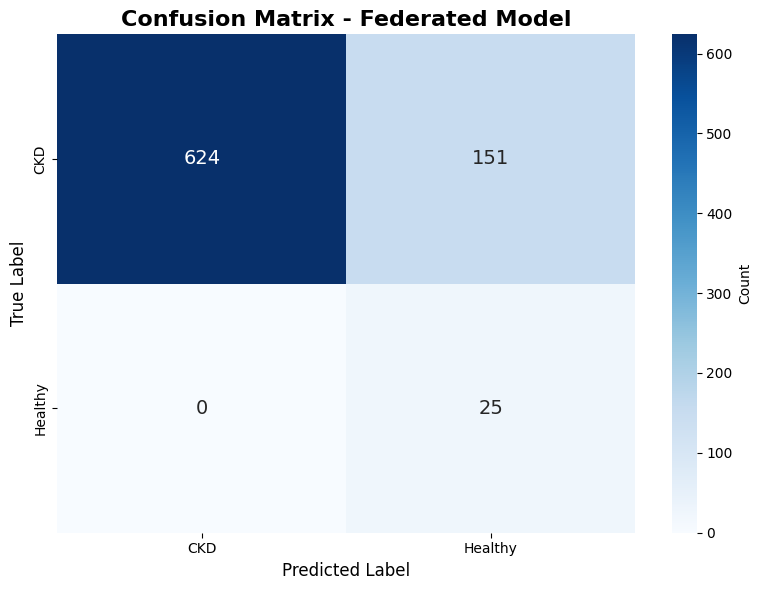

In [8]:
#  Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
plt.title('Confusion Matrix - Federated Model', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

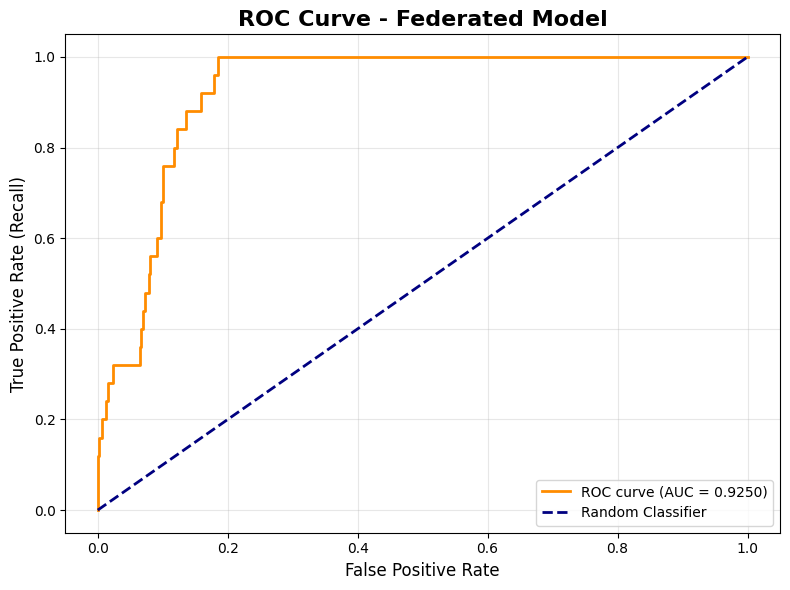

In [9]:
# Plot ROC Curve
if auc_roc is not None and len(unique_test) > 1:
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob[:, 1])
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('ROC Curve - Federated Model', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/roc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

In [10]:
# Threshold Analysis
if auc_roc is not None:
    print("Threshold Analysis:")
    print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'F1-Score':<12} {'FN':<10}")
    print("-" * 60)
    
    thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
    for threshold in thresholds_to_test:
        y_pred_thresh = (y_pred_prob[:, 1] >= threshold).astype(int)
        rec_thresh = recall_score(y_test, y_pred_thresh, zero_division=0)
        prec_thresh = precision_score(y_test, y_pred_thresh, zero_division=0)
        f1_thresh = f1_score(y_test, y_pred_thresh, zero_division=0)
        cm_thresh = confusion_matrix(y_test, y_pred_thresh, labels=[0, 1])
        fn_thresh = cm_thresh[1, 0]
        
        print(f"{threshold:<12.1f} {rec_thresh:<10.4f} {prec_thresh:<12.4f} {f1_thresh:<12.4f} {fn_thresh:<10d}")

Threshold Analysis:
Threshold    Recall     Precision    F1-Score     FN        
------------------------------------------------------------
0.3          1.0000     0.1116       0.2008       0         
0.4          0.9200     0.1565       0.2674       2         
0.5          0.5600     0.1795       0.2718       11        
0.6          0.3200     0.2353       0.2712       17        
0.7          0.1600     0.5000       0.2424       21        


In [11]:
# Per-Client Evaluation
with open('../data/client_latent_features.pkl', 'rb') as f:
    client_latent_features = pickle.load(f)

with open('../data/client_data_processed.pkl', 'rb') as f:
    client_data_processed = pickle.load(f)

client_metrics = []

for cid in range(len(client_latent_features)):
    X_client = client_latent_features[cid]
    y_client = client_data_processed[cid][1].astype(np.int32)
    
    if len(y_client) == 0:
        continue
    
    y_pred_client = np.argmax(global_model.predict(X_client, verbose=0), axis=1)
    unique_client = np.unique(np.concatenate([y_client, y_pred_client]))
    
    acc = accuracy_score(y_client, y_pred_client)
    
    if len(unique_client) > 1:
        prec = precision_score(y_client, y_pred_client, average='binary', zero_division=0)
        rec = recall_score(y_client, y_pred_client, average='binary', zero_division=0)
        f1_c = f1_score(y_client, y_pred_client, average='binary', zero_division=0)
    else:
        prec = 1.0 if unique_client[0] in y_pred_client else 0.0
        rec = 1.0 if unique_client[0] in y_client else 0.0
        f1_c = 1.0 if (unique_client[0] in y_client and unique_client[0] in y_pred_client) else 0.0
    
    client_metrics.append({
        'Client': cid + 1, 'Samples': len(y_client),
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1_c
    })
    
    print(f"Client {cid+1}: Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1_c:.4f}")

client_metrics_df = pd.DataFrame(client_metrics)

Client 1: Acc=0.8492 | Prec=0.8441 | Rec=0.7333 | F1=0.7848
Client 2: Acc=0.6895 | Prec=0.7041 | Rec=0.2968 | F1=0.4175
Client 3: Acc=0.8677 | Prec=0.8053 | Rec=0.8538 | F1=0.8288
Client 4: Acc=0.7073 | Prec=0.6624 | Rec=0.4473 | F1=0.5340


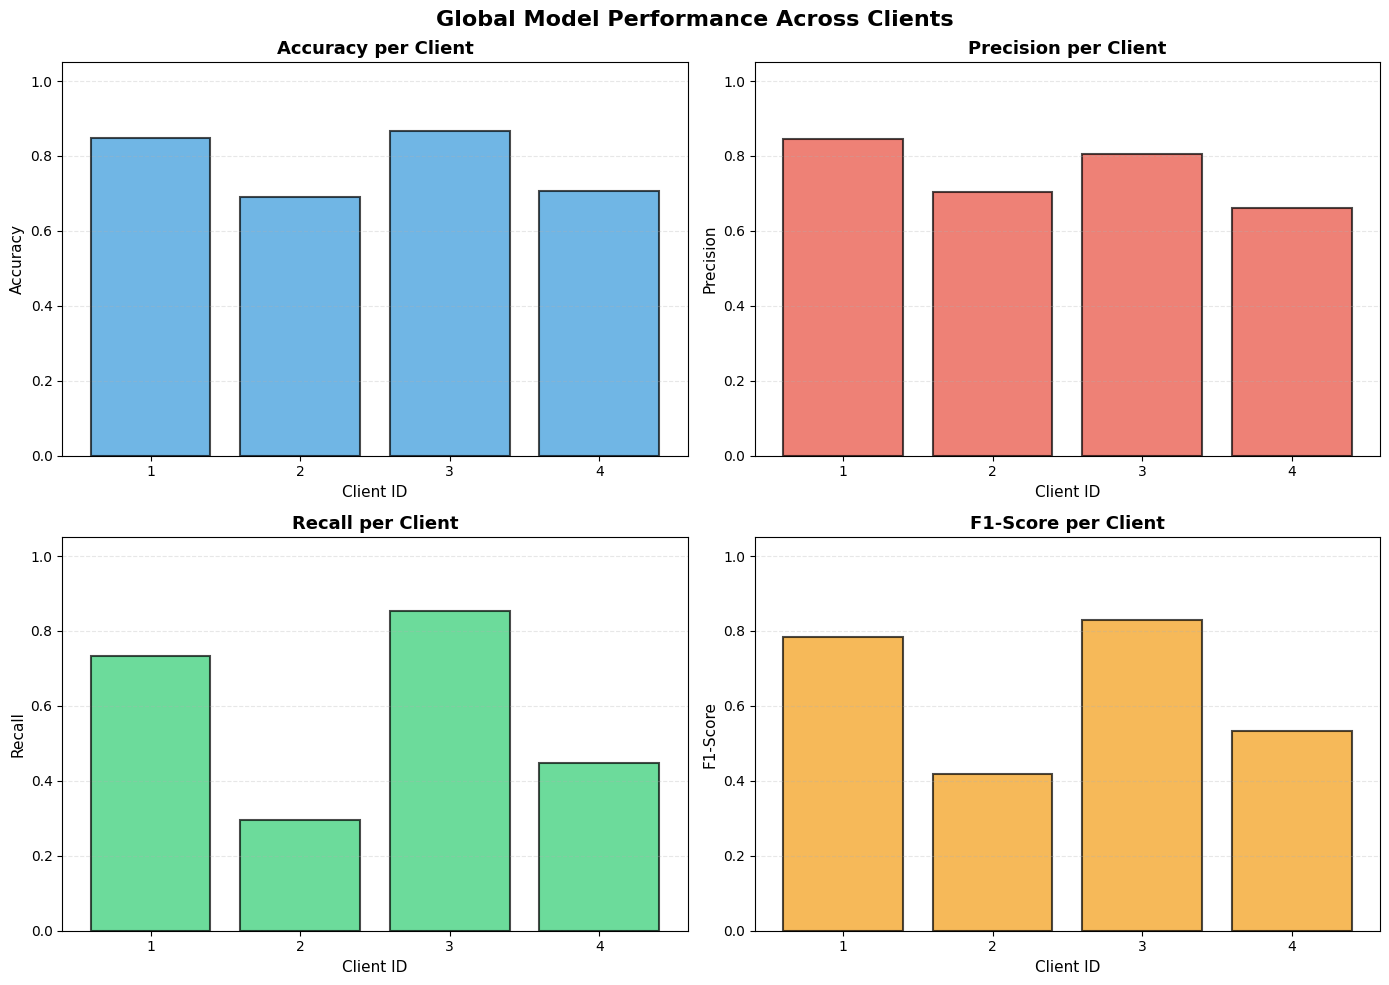

In [12]:
# Plot Per-Client Metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for ax, metric, color in zip(axes.flatten(), metrics_to_plot, colors):
    ax.bar(client_metrics_df['Client'], client_metrics_df[metric],
           color=color, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Client ID', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} per Client', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticks(client_metrics_df['Client'])

plt.suptitle('Global Model Performance Across Clients', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_client_performance.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Save Results
overall_metrics = pd.DataFrame({
    'Metric': ['Recall', 'F1-Score', 'Specificity', 'Accuracy', 'Precision', 'AUC-ROC', 
               'False Negatives', 'True Positives'],
    'Value': [recall, f1, specificity, accuracy, precision, auc_roc if auc_roc else 'N/A', fn, tp]
})

overall_metrics.to_csv(f'{RESULTS_DIR}/overall_metrics.csv', index=False)
client_metrics_df.to_csv(f'{RESULTS_DIR}/per_client_metrics.csv', index=False)

print("Saved results to:")
print("  - overall_metrics.csv")
print("  - per_client_metrics.csv")
print("  - confusion_matrix.png")
print("  - roc_curve.png")
print("  - per_client_performance.png")

Saved results to:
  - overall_metrics.csv
  - per_client_metrics.csv
  - confusion_matrix.png
  - roc_curve.png
  - per_client_performance.png


In [14]:
# Summary Statistics
summary = client_metrics_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].describe()
print(summary)

best_recall_client = client_metrics_df.loc[client_metrics_df['Recall'].idxmax()]
worst_recall_client = client_metrics_df.loc[client_metrics_df['Recall'].idxmin()]
best_f1_client = client_metrics_df.loc[client_metrics_df['F1-Score'].idxmax()]

print(f"\nBest recall: Client {best_recall_client['Client']} ({best_recall_client['Recall']:.4f})")
print(f"Worst recall: Client {worst_recall_client['Client']} ({worst_recall_client['Recall']:.4f})")
print(f"Best F1: Client {best_f1_client['Client']} ({best_f1_client['F1-Score']:.4f})")

       Accuracy  Precision    Recall  F1-Score
count  4.000000   4.000000  4.000000  4.000000
mean   0.778427   0.753959  0.582796  0.641297
std    0.093015   0.084889  0.255766  0.197762
min    0.689516   0.662420  0.296774  0.417549
25%    0.702823   0.693666  0.409677  0.504901
50%    0.778226   0.754678  0.590323  0.659414
75%    0.853831   0.814970  0.763441  0.795810
max    0.867742   0.844059  0.853763  0.828810

Best recall: Client 3.0 (0.8538)
Worst recall: Client 2.0 (0.2968)
Best F1: Client 3.0 (0.8288)


In [15]:
import shutil

# Copy Round 3 as the default model for all other notebooks
shutil.copy(
    f'../models/global_classifier_round{BEST_ROUND}.keras',
    '../models/global_classifier.keras'
)

print(f" Copied Round {BEST_ROUND} as default global_classifier.keras")

 Copied Round 3 as default global_classifier.keras


In [16]:

production_config = {
    # Model Information
    'model_file': f'global_classifier_round{BEST_ROUND}.keras',
    'default_model': 'global_classifier.keras',
    'model_path': MODEL_PATH,
    'round': BEST_ROUND,
    'threshold':best_threshold,
    
    # Model Architecture
    'latent_dim': LATENT_DIM,
    'num_classes': NUM_CLASSES,
    
    # Performance Metrics (from current run)
    'performance': {
        'accuracy': float(accuracy),
        'recall': float(recall),
        'specificity': float(specificity),
        'precision': float(precision),
        'f1_score': float(f1),
        'auc_roc': float(auc_roc) if auc_roc else None,
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp),
        'true_negatives': int(tn)
    },
    
    # Clinical Information
    'clinical_note': f'Production model for CKD screening - {recall:.1%} recall with {specificity:.1%} specificity',
    'use_case': 'Primary screening for chronic kidney disease',
    'date_validated': '2025-12-13',
    
    # Label Mapping
    'label_mapping': {
        0: 'CKD',
        1: 'Healthy'
    },
    
    # Important Notes
    'notes': [
        'LABEL MAPPING: 0=CKD, 1=Healthy (reversed from initial expectation)',
        f'Recall (CKD detection): {recall:.1%}',
        f'Specificity: {specificity:.1%}',
        f'False Negatives: {fn}, False Positives: {fp}',
        'Optimized for medical screening where missing cases is critical'
    ]
}

# Save as pickle
with open('../models/production_config.pkl', 'wb') as f:
    pickle.dump(production_config, f)

# Save as JSON for readability
import json
with open('../models/production_config.json', 'w') as f:
    json.dump(production_config, f, indent=2)

print("Saved production configuration:")
print("   - ../models/production_config.pkl (for Python)")
print("   - ../models/production_config.json (human-readable)")
print("\nProduction Model Summary:")
print(f"   Model File: {production_config['model_file']}")
print(f"   Threshold: {production_config['threshold']}")
print(f"   Accuracy: {production_config['performance']['accuracy']:.4f}")
print(f"   Recall: {production_config['performance']['recall']:.4f}")
print(f"   Specificity: {production_config['performance']['specificity']:.4f}")
print(f"   False Negatives: {production_config['performance']['false_negatives']}")
print("="*70)

Saved production configuration:
   - ../models/production_config.pkl (for Python)
   - ../models/production_config.json (human-readable)

Production Model Summary:
   Model File: global_classifier_round3.keras
   Threshold: 0.3500000000000001
   Accuracy: 0.8113
   Recall: 1.0000
   Specificity: 0.8052
   False Negatives: 0
